*****

<p style="text-align:center; font-size:28px; font-weight:bold">LABORATORIO: Eliminación de anomalías de la imagen</p>

*****

**Presentado por:** Omar Javier Daza Leguizamón

**Presentado a:** Luis Fernando Barajas Ardila

**Asignatura:** Percepción computacional

**Fecha:** 4 de octubre de 2026

*****

<p align="center">
  <img src="https://campusvirtual.colombia.unir.net/pluginfile.php/2/core_admin/logo/0x200/1789455527/UNIR_Fundacion_Universitaria_COLOMBIA_color_h.png" alt="Logo centrado" width="500">

*****

## 1. Integrantes

<mark>NOTA:</mark> Este trabajo se desarrolló y se presenta de forma individual debido a que, por causas laborales, resultó difícil coordinar trabajo colaborativo con otros estudiantes de la asignatura. El nombre del responsable de este Notebook aparece en el encabezado.
*****

## 2. Descripción del problema

Como parte de las actividades de la gestión de infraestructura vial, la auscultación de pavimentos es una de las más importantes por su impacto en el costo de las intervenciones cuando estas son de tipo correctivo. Uno de los referentes que describen los métodos de cuantificación de los deterioros es la norma ASTM D6433, en la cual se presenta el índice de condición del pavimento (PCI). Este índice clasifica los deterioros del pavimento a partir del tipo, la severidad y la extensión, siendo las fisuras uno de los deterioros de mayor frecuencia y los primeros en aparecer (Shahin, 2005). En este contexto, debido a la subjetividad y los altos costos de los métodos de inspección visual tradicionales, se ha extendido  el uso de imágenes como método alternativo de auscultación (Koch et al., 2015; Zakeri et al., 2017).

Uno de los problemas a resolver durante el procesamiento y análisis de imágenes de pavimentos está relacionado con las degradaciones causadas por el ruido impulsivo o "sal y pimienta", el cual causa que una parte del conjunto de píxeles de la imagen quede saturada en negro (0) o en blanco (255); valores que no reflejan la situación real. Estos problemas pueden ser causados por fallos en el sensor y errores durante la transmisión o el almacenamiento de los datos (Gonzalez y Woods, 2018; UNIR, s. f.,  tema 4). 

Uno de los métodos clásicos para el tratamiento de este tipo de defecto en las imágenes es el filtrado de mediana, el cual es eficaz para este caso porque descarta los valores extremos de cada vecindad (Gonzalez y Woods, 2018). Sin embargo, presenta el inconveniente de que aplica la misma operación a todos los píxeles (afectados o no) y elimina las estructuras que podrían ser de interés y que estarían ocupando menos de la mitad de la ventana (UNIR, s. f., tema 5). Justamente esta situación se presenta en las imágenes de pavimentos, por lo que el filtrado tradicional, además de eliminar el ruido, eliminaría el dato que es de utilidad en el proceso de auscultación. Esta situación ha llevado al uso de métodos de filtrado que primero identifican los píxeles afectados y después los corrigen (Hwang y Haddad, 1995; Chan et al., 2005)

En este contexto, el objetivo de esta actividad es desarrollar e implementar un método de eliminación de ruido impulsivo que detecte los píxeles anómalos y corrija únicamente estos, con el fin de restaurar imágenes de pavimento preservando las fisuras, y evaluar su desempeño frente al filtro de mediana clásico en imágenes del conjunto CrackForest con distintas densidades de ruido.

## 3.Imágenes y generación de ruido sintético

### 3.1 Importación de librerías, parámetros globales

In [1]:
# Importar librerías y definir parámetros globales

import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.io import loadmat

# Parámetros globales: se aplican por igual a todas las imágenes (solución no ad hoc)
RUTA = "data"
IMAGENES = [49, 96, 35, 97]          # casos seleccionados del CrackForest
DENSIDADES = [0.05, 0.15, 0.30]      # proporción de píxeles afectados por el ruido
SEMILLA = 2026                       # semilla fija: el ruido es idéntico en cada ejecución

generador = np.random.default_rng(SEMILLA)

### 3.2 Descripción de las imágenes

Se utiliza el conjunto de datos CrackForest (Shi et al., 2016), el cual está compuesto por 118 imágenes de superficies de pavimento urbano de tamaño 480 × 320 píxeles. Las imágenes están acompañadas de máscaras de fisuras generadas manualmente a nivel de píxel. Las imágenes se descargaron del sitio web https://github.com/cuilimeng/CrackForest-dataset y se utilizan en este ejercicio académico considerando que son distribuidas con autorización de uso para fines de investigación no comerciales. Las imágenes están en escala de grises de 8 bits con valores de 0 a 255.

Se seleccionaron cuatro imágenes que presentan situaciones de cobertura de fisuras diferentes: una de baja cobertura (049), una de cobertura mediana (096) y dos de mayor cobertura (035 y 097). Esto permite que la propuesta metodológica se ponga a prueba desde una fisura aislada y tenue hasta una red densa de fisuras con numerosas intersecciones.

| Imagen | Patrón de fisuración observado            | Píxeles de fisura | Reto para el método                          |
|--------|-------------------------------------------|-------------------|----------------------------------------------|
| 049    | Longitudinal, muy fina y de bajo contraste | 0,35 %            | La fisura se confunde con la textura         |
| 096    | Longitudinal definida                     | 1,32 %            | Caso típico del conjunto                     |
| 035    | Fisuras anchas, ramificadas               | 6,22 %            | Fisuras gruesas con zonas oscuras extensas   |
| 097    | Red de fisuras interconectadas            | 6,33 %            | Muchas intersecciones y fisuras próximas     |

La descripción del patrón es visual; no constituye una clasificación de daños según ASTM D6433, que exigiría conocer las dimensiones reales de la superficie fotografiada.

In [2]:
# Función para cargar la imagen y la máscara de fisura

def cargar_par(numero):
    """Devuelve la imagen en escala de grises y la máscara de fisura (verdad de terreno)."""
    nombre = f"{numero:03d}"
    imagen = cv2.imread(f"{RUTA}/image/{nombre}.jpg", cv2.IMREAD_GRAYSCALE)
    gt = loadmat(f"{RUTA}/groundTruth/{nombre}.mat")
    mascara = gt["groundTruth"][0, 0]["Segmentation"] == 2
    return imagen, mascara


### 3.3 Generación de ruido sintético

Las imágenes originales no contienen ruido impulsivo, por lo que este se agregó de forma controlada, utilizando densidades de 5 %, 15 % y 30 %, con igual proporción de píxeles blancos y negros. Este procedimiento, habitual en la evaluación de filtros de ruido impulsivo
(Hwang y Haddad, 1995; Chan et al., 2005), permite una evaluación rigurosa por tres razones:

1. **Se conoce la imagen limpia:** La restauración se compara con el original permitiendo calcular métricas objetivas de calidad.
2. **Se conoce la posición de cada impulso:** Permite medir la exactitud de la etapa de detección, identificando cuántos impulsos encuentra y cuántos píxeles sanos confunde con ruido, en particular sobre las fisuras.
3. **La densidad se controla y es reproducible:** El método se evalúa en condiciones de dificultad variable, y una semilla aleatoria fija garantiza resultados idénticos en cada ejecución con fines de verificación posterior.

Es importante mencionar la limitación de que el ruido real puede presentar patrones distintos al modelo uniforme empleado en este notebook, por ejemplo agrupaciones de píxeles defectuosos.


In [3]:
# Función para agregar ruido sal y pimienta de forma sintética

def agregar_sal_pimienta(imagen, densidad, generador):
    """Agrega ruido sal y pimienta. Devuelve la imagen ruidosa y la máscara del ruido."""
    seleccion = generador.random(imagen.shape) < densidad   # Los píxeles que se alteran
    es_sal = generador.random(imagen.shape) < 0.5  # Píxeles alterados que se convierten en sal (el resto es pimienta)
    ruidosa = imagen.copy()
    ruidosa[seleccion & es_sal] = 255                       
    ruidosa[seleccion & ~es_sal] = 0
    return ruidosa, seleccion

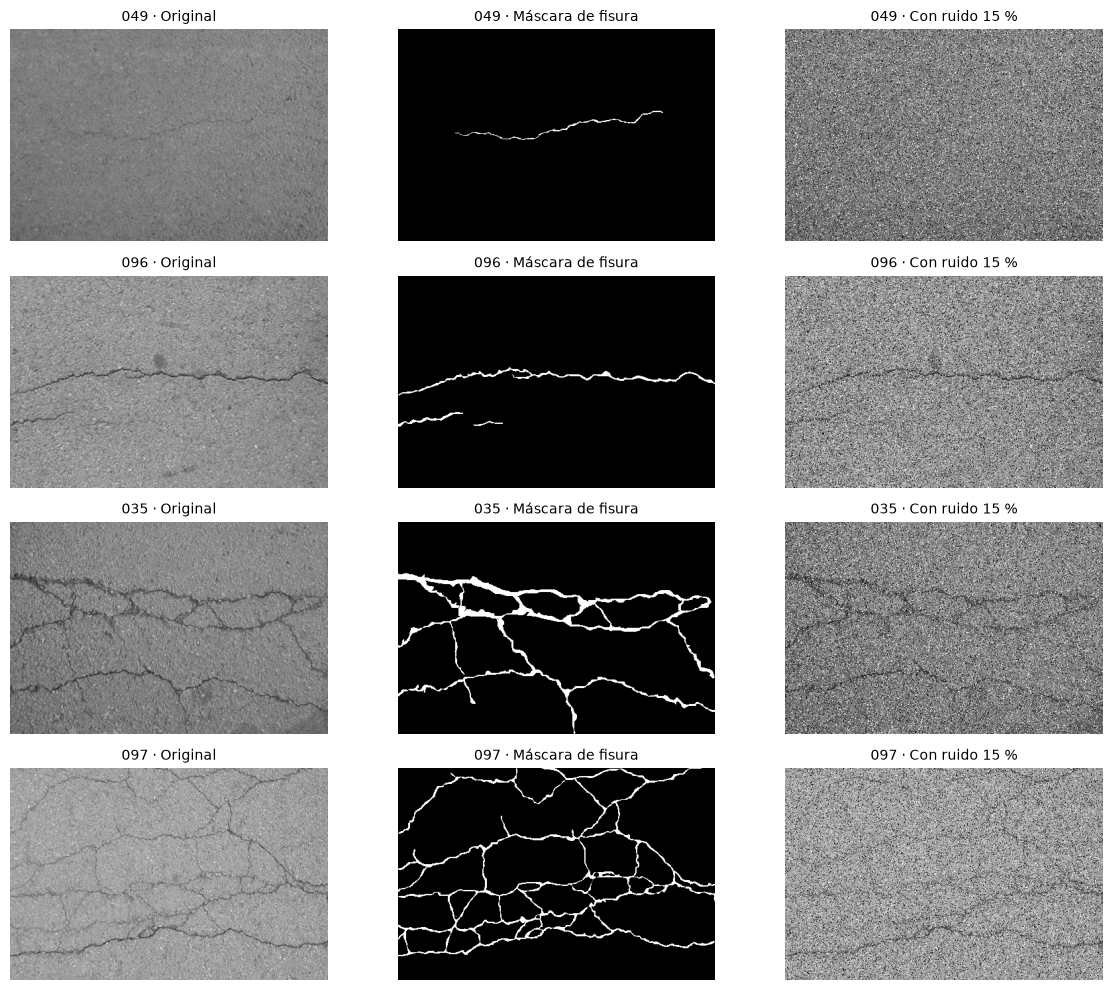

In [4]:
# Visualización de las imágenes que se analizan en este notebook, 
# con sus máscaras de fisura y una versión ruidosa (15 % de ruido sal y pimienta)

generador = np.random.default_rng(SEMILLA)   # reinicia la secuencia para reproducibilidad

fig, ejes = plt.subplots(len(IMAGENES), 3, figsize=(12, 10))
for i, n in enumerate(IMAGENES):
    img, fisura = cargar_par(n)
    ruidosa, _ = agregar_sal_pimienta(img, 0.15, generador)
    paneles = [(img, "Original", 255), (fisura, "Máscara de fisura", 1), (ruidosa, "Con ruido 15 %", 255)]
    for j, (dato, titulo, vmax) in enumerate(paneles):
        ejes[i, j].imshow(dato, cmap="gray", vmin=0, vmax=vmax)
        ejes[i, j].set_title(f"{n:03d} · {titulo}", fontsize=10)
        ejes[i, j].axis("off")
plt.tight_layout()
plt.show()

## 4. Solución propuesta

La lógica del método se centro en identificar lo que es realmente ruido y corregirlo. Se propone un método alternativo al filtrado clásico con mediana, en el cual se identifican los impulsos y posteriormente son reemplazados. Esto con el proposito de los pixeles sanos se conserven, en particular las fisuras, que son las de mayor interés para el análisis de las imágenes.

### 4.1 Etapa 1: detección de impulsos (`detectar_impulsos`)

Un píxel se marca como impulso si cumple simultáneamente dos condiciones:

1. **Valor extremo:** su intensidad es 0 o 255, los únicos valores que produce el ruido impulsivo.
2. **Aislamiento:** en su vecindario 3 × 3, a lo sumo K de sus 8 vecinos tienen una intensidad similar (diferencia ≤ T).

Con la primera condición se descarta la textura del pavimento y las fisuras, las cuales en las imágenes analizadas no alcanzan valores extremos. Por otro lado, la segunda permite distinguir un impulso de una zona saturada legítima, como un reflejo brillante o una sombra profunda. Esto último considerando que un impulso es un punto aislado, mientras que un reflejo forma una mancha de píxeles similares.

In [5]:
# Etapa 1 del método propuesto: Detección de impulsos

def detectar_impulsos(imagen, K=3, T=30):
    """Detecta impulsos sal y pimienta (etapa 1 del método propuesto).

    Un píxel se marca como impulso si cumple dos condiciones:
      1. Tiene valores extremos (0 o 255).
      2. Tiene pocos vecinos similares (<= K) en una ventana 3x3 alrededor.

    Parámetros
    ----------
    imagen : matriz uint8 en escala de grises.
    K : int, número máximo de vecinos similares para considerar un píxel como impulso (definido por el usuario).
    T : int, umbral de tolerancia para considerar vecinos similares (diferencia absoluta <= T).

    Devuelve
    --------
    mascara : matriz booleana, True en los píxeles detectados como impulso.
    """
    alto, ancho = imagen.shape
    g = 1

    # Convertir la imagen a tipo int para evitar problemas de overflow al restar
    imagen_int = imagen.astype(int)

    # Rellenar la imagen con reflejo para manejar los bordes - creación de máscara
    p = np.pad(imagen_int, g, mode="reflect")
    mascara = np.zeros(imagen.shape, dtype=bool)

    # Detecta los impulsos recorriendo la imagen y evaluando la ventana 3x3,
    # contando los vecinos que están dentro del umbral T respecto al valor central y
    # verificando que el valor central sea 0 o 255
    for y in range(alto):
        for x in range(ancho):
            centro = p[y + g, x + g] 
            ventana = p[y : y + 3, x : x + 3] 
            cantidad = np.sum(np.abs(ventana - centro) <= T) - 1 
            if cantidad <= K and (centro == 0 or centro == 255): 
                mascara[y, x] = True
    
    return mascara

### 4.2 Etapa 2: corrección con ventana adaptativa (`corregir_impulsos`)

Durante esta segunda etapa del método, cada uno de los píxel detectado se reemplaza por la **mediana de sus vecinos limpios**, es decir, no considera en el cálculo los marcados como ruido. El proceso empieza con una ventana de 3 ×3, evaluando si contiene menos de N vecinos limpios, y de ser así, la ventana crece a 5 × 5 y luego a 7 × 7, hasta un máximo V_max. Este proceso permite que cada impulso se estime con la información más cercana posible y solo se recurre a vecinos lejanos cuando el ruido es denso. En el algoritmo, cuando se alcanza el valor de V_max y no hay suficientes vecinos limpios, se usa la mediana de los datos disponibles. La corrección lee siempre la imagen de entrada y escribe en una copia, de modo que el resultado no depende del orden de recorrido.

In [6]:
# Etapa 2 del método propuesto: corrección con ventana adaptativa

def corregir_impulsos(imagen, mascara, N=5, V_max=7):
    """Reemplaza cada impulso por la mediana de sus vecinos limpios.
    
    Parámetros
    ----------
    imagen : matriz uint8 en escala de grises.
    mascara : matriz booleana, True en los píxeles detectados como impulso.
    N : int, número mínimo de vecinos limpios para calcular la mediana (definido por el usuario).
    V_max : int, tamaño máximo de la ventana adaptativa (definido por el usuario).

    Devuelve
    --------
    salida : matriz uint8, imagen corregida.
    """
    g = V_max // 2 # grosor del relleno de bordes, suficiente para la ventana más grande.

    # Rellenar la imagen y la máscara con reflejo para manejar los bordes
    p = np.pad(imagen, g, mode="reflect")
    pm = np.pad(mascara, g, mode="reflect")
    
    salida = imagen.copy()

    # Recorre todos los píxeles marcados como impulsos y aplica la corrección
    for y, x in zip(*np.nonzero(mascara)):
        V = 3
        corregido = False

        # Mientras no se haya corregido y el tamaño de la ventana no supere V_max, 
        # se busca una ventana de vecinos limpios
        while not corregido and V <= V_max:
            h = V // 2
            ventana = p[y + g - h : y + g + h + 1,  x + g - h : x + g + h + 1]
            ventana_mascara = pm[y + g - h : y + g + h + 1,  x + g - h : x + g + h + 1]
            limpios = ventana[~ventana_mascara]   # ~ = "no": los NO marcados
            if limpios.size >= N:
                    salida[y, x] = np.median(limpios)
                    corregido = True
            else:
                V = V + 2
        if not corregido and limpios.size > 0:
            salida[y, x] = np.median(limpios)
    return salida

### 4.3 Pasadas sucesivas (`filtro_propuesto`)

Cuando el ruido es denso, algunos impulsos forman grupos y no cumplen la condición de aislamiento. Tras una primera pasada de detección y corrección, sus vecinos ya corregidos los dejan aislados, y una segunda pasada los detecta. El método completo aplica P pasadas.

In [7]:
# Método completo: P pasadas de detección + corrección.

def filtro_propuesto(imagen, P=2, K=3, T=30, N=5, V_max=7):
    """Aplica el método propuesto de detección y corrección de impulsos.

    Parámetros
    ----------
    imagen : matriz uint8 en escala de grises.
    P : int, número de pasadas de detección + corrección (definido por el usuario).
    K : int, número máximo de vecinos similares para considerar un píxel como impulso. (definido por el usuario).
    T : int, umbral de tolerancia para considerar vecinos similares (diferencia absoluta <= T).
    N : int, número mínimo de vecinos limpios para calcular la mediana (definido por el usuario).
    V_max : int, tamaño máximo de la ventana adaptativa (definido por el usuario).

    Devuelve
    --------
    salida : matriz uint8, imagen corregida.
    """
    resultado = imagen.copy()
    for _ in range(P):
        mascara = detectar_impulsos(resultado, K=K, T=T)
        resultado = corregir_impulsos(resultado, mascara, N=N, V_max=V_max)
    return resultado

### 4.4 Métricas de medición de calidad de la restauración
 
Con el fin de tener métricas para determinar la calidad de restauración de la imagen al aplicar el método propuesto, se utilizan el PSNR (Peak Signal to Noise Ratio) y el SSIM (Structural Similarity Index). El PSNR implica el cálculo del error cuadrático medio (MSE), obtenido al comparar la imagen original y la corregida, y la conversión de este valor a decibelios. Por otro lado, el SSIM en lugar de recorrer la imagen pixel a pixel, hace un recorrido de la imagen considerando pequeñas zonas en cada una de ellas se comparan el brillo medio, la variación de la intensidad y la coincidencia de patrones (Want et al., 2004). 

In [8]:
# Funciones de evaluación: PSNR y SSIM

def psnr(referencia, prueba, mascara=None):
    """PSNR en dB. Si se da una máscara, se calcula solo en esos píxeles.
    Parámetros
    ----------
    referencia : matriz uint8
        Imagen de referencia.
    prueba : matriz uint8
        Imagen a evaluar.
    mascara : matriz booleana, opcional
        Máscara para calcular PSNR solo en ciertos píxeles.

    Devuelve
    --------
    psnr : float
        PSNR en dB.
    """
    ref = referencia.astype(np.float64)
    pru = prueba.astype(np.float64)
    if mascara is not None:
        ref, pru = ref[mascara], pru[mascara]
    mse = np.mean((ref - pru) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

def ssim(referencia, prueba):
    """SSIM de Wang et al. (2004): ventana gaussiana 11x11, sigma 1.5.
    Parámetros
    ----------
    referencia : matriz uint8
        Imagen de referencia.
    prueba : matriz uint8
        Imagen a evaluar.

    Devuelve
    --------
    ssim : float
        SSIM.
    """
    C1, C2 = (0.01 * 255) ** 2, (0.03 * 255) ** 2
    x = referencia.astype(np.float64)
    y = prueba.astype(np.float64)
    suavizar = lambda m: cv2.GaussianBlur(m, (11, 11), 1.5)
    mu_x, mu_y = suavizar(x), suavizar(y)
    var_x = suavizar(x * x) - mu_x ** 2
    var_y = suavizar(y * y) - mu_y ** 2
    cov_xy = suavizar(x * y) - mu_x * mu_y
    mapa = ((2 * mu_x * mu_y + C1) * (2 * cov_xy + C2)) / \
           ((mu_x ** 2 + mu_y ** 2 + C1) * (var_x + var_y + C2))
    return float(mapa.mean())

### 4.5 Parámetros y justificación

Los mismos valores se aplican a todas las imágenes y densidades.

| Parámetro | Valor | Justificación |
|---|---|---|
| T (tolerancia de similitud) | 30 | Agrupa como similares los píxeles de una misma zona saturada (por ejemplo los reflejos entre 225 y 255), para evitar confundir un impulso con la textura propia del asfalto |
| K (máx. vecinos similares) | 3 | Ver análisis a continuación |
| N (mín. vecinos limpios) | 5 | Con 15 % de ruido, solo el 2,1 % de los impulsos necesita ampliar la ventana; con 30 %, el 19,4 %. En pruebas preliminares, N = 3, 5 y 6 difirieron en menos de 0,2 dB de PSNR |
| V_max (ventana máxima) | 7 | Con 30 % de ruido, la probabilidad de que una ventana de 5 × 5 sea insuficiente es del orden de 10⁻⁷, y la de una de 7 × 7, de 10⁻¹⁹: el límite garantiza que el proceso termina sin afectar los resultados |
| P (pasadas) | 2 | Con 30 % de ruido, reduce los impulsos residuales del 0,66 % al 0,03 % y eleva el PSNR medio de 26,2 a 31,2 dB respecto a una sola pasada; una tercera pasada solo aporta 0,5 dB. |

**Elección de K:** Un impulso o pixel con ruido puede tener vecinos del mismo color por azar. Considerando una densidad d, cada vecino es un impulso del mismo color con probabilidad d/2, y el número de estos "gemelos" sigue una distribución binomial B(8, d/2). La probabilidad de tener como máximo K = 3 gemelos, y por tanto de ser detectable en la primera pasada, es del 100 % con 5 % de ruido, del 99,8 % con 15 % y del 97,9 % con 30 %, valores que coinciden con las tasas observadas experimentalmente.

### 4.6 Justificación de la metodología presentada en el contexto de las instrucciones de la actividad

El método y su implementación no toman directamente una función existente en las librerías disponibles para la solución de este tipo de problemáticas. Tanto la detección, como la corrección, se implementan de forma propia atendiendo a un interés temático propio de mi desempeño profesional. En comparación a una solución clásica, el cual modifica todos los pixeles con una ventana fija, el método propuesto primero separa la detección de la corrección en dos etapas independientes. Además, incluye un criterio de selección de impulsos que preserva las estructuras finas y zonas saturadas que no son anomalías. Finalmente, el método adapta el tamaño de la ventana a la densidad local del ruido, calculando cada valor a partir de los vecinos limpios.

### 4.7 Relación con la literatura

La idea de la ventana adaptativa, implementada en el método, surge del filtro del medidana adaptativo presentado por los autores Hwang y Haddad (1995), mientras que la estrategia para detectar primero y corregir después sigue la línea de los filtros de tipo conmutado, como el presentado por Chan et al. (2005). la principal diferencia de esta propuesta con la presentada por Hwang y Haddad (1995) es que su filtro trata como impulso cualquier píxel igual al mínimo o al máximo de la ventana, esto puede alterar el centro oscuro de una fisura y esto no es aceptable para este caso; por otro lado, el método propuesto solo actúa sobre valores 0 o 255 aislados y calcula la mediana excluyendo los píxeles ruidosos y trabaja en pasadas.

## 5. Ejecución del algoritmo para imágenes propuestas

### 5.1 Detección de impulsos de imagen 96

Como se describió en la propuesta metodológica, se tienen dos etapas de implementación. A continuación, con fines ilustrativos, se presenta la detección de impulsos (ruido sal y pimienta) de la imagen 96 con una densidad de ruido del 15%. La generación sintética de ruido insertó 23198 pixeles de ruido, de los cuales se detectaron el 99.8%, siendo un valor que demuestra la utilidad del algoritmo para la detección de anomalias. 

Impulsos insertados: 23198
  detectados: 23148 (99.8 %)
  no detectados en la 1.ª pasada: 50
Píxeles sanos marcados por error: 0 (sobre la fisura: 0)


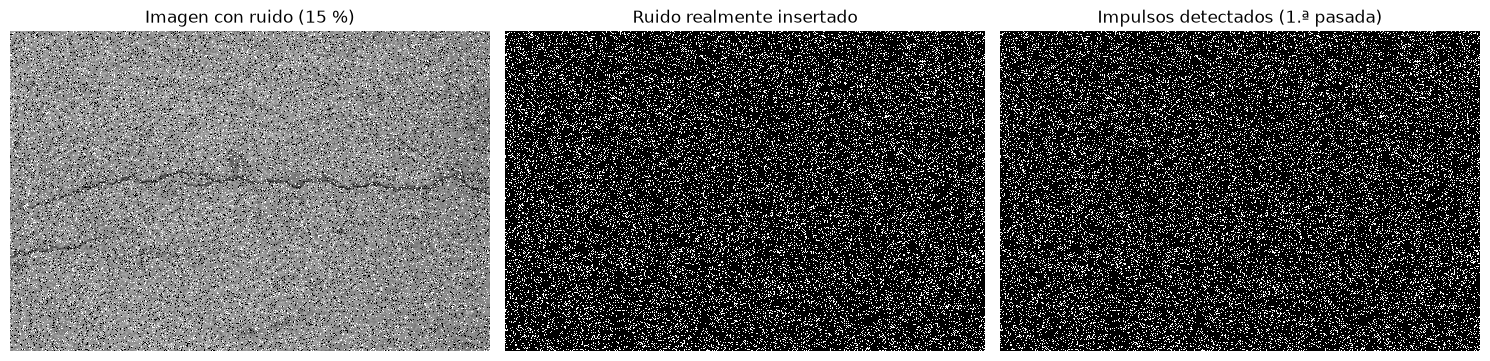

In [9]:
# Evaluación de la primera etapa: detección de impulsos

# Se evalúa la primera etapa del método propuesto (detección de impulsos) en la imagen 96, con un 15 % de ruido sal y pimienta.
img, fisura = cargar_par(96)
gen = np.random.default_rng(SEMILLA)
ruidosa, mascara_ruido = agregar_sal_pimienta(img, 0.15, gen)
detectados = detectar_impulsos(ruidosa)

# Estadísticas de la detección de impulsos
aciertos = np.sum(detectados & mascara_ruido)
omitidos = np.sum(~detectados & mascara_ruido)
falsos = np.sum(detectados & ~mascara_ruido)
falsos_fisura = np.sum(detectados & ~mascara_ruido & fisura)

# Impresión de estadísticas
print(f"Impulsos insertados: {mascara_ruido.sum()}")
print(f"  detectados: {aciertos} ({100 * aciertos / mascara_ruido.sum():.1f} %)")
print(f"  no detectados en la 1.ª pasada: {omitidos}")
print(f"Píxeles sanos marcados por error: {falsos} (sobre la fisura: {falsos_fisura})")

# Visualización de la imagen ruidosa, la máscara de ruido y los impulsos detectados
fig, ejes = plt.subplots(1, 3, figsize=(15, 3.6))
titulos = ["Imagen con ruido (15 %)", "Ruido realmente insertado", "Impulsos detectados (1.ª pasada)"]
for eje, dato, titulo in zip(ejes, [ruidosa, mascara_ruido, detectados], titulos):
    eje.imshow(dato, cmap="gray")
    eje.set_title(titulo)
    eje.axis("off")
plt.tight_layout()
plt.show()

En las imagenes generadas, se puede apreciar la imagen con el ruido del 15%, en la cual se pierde el detalle de la fisura sobre el pavimento, lo cual es una situación desventajosa para la implementación de algoritmos de detección del daño. Además, como se puede ver en las dos figuras que presentan el ruido insertado y detectado los patrones visuales del ruido son bastante similares. 

### 5.2 Corrección de anomalías de la imagen 96

Continuando con el análisis de la imagen 96, se presenta a continuación la corrección de las anomalías detectadas previamente. Se presenta una comparación entre el método propuesto y la aplicación de filtros de mediana para ventanas 3X3 y 5X5.

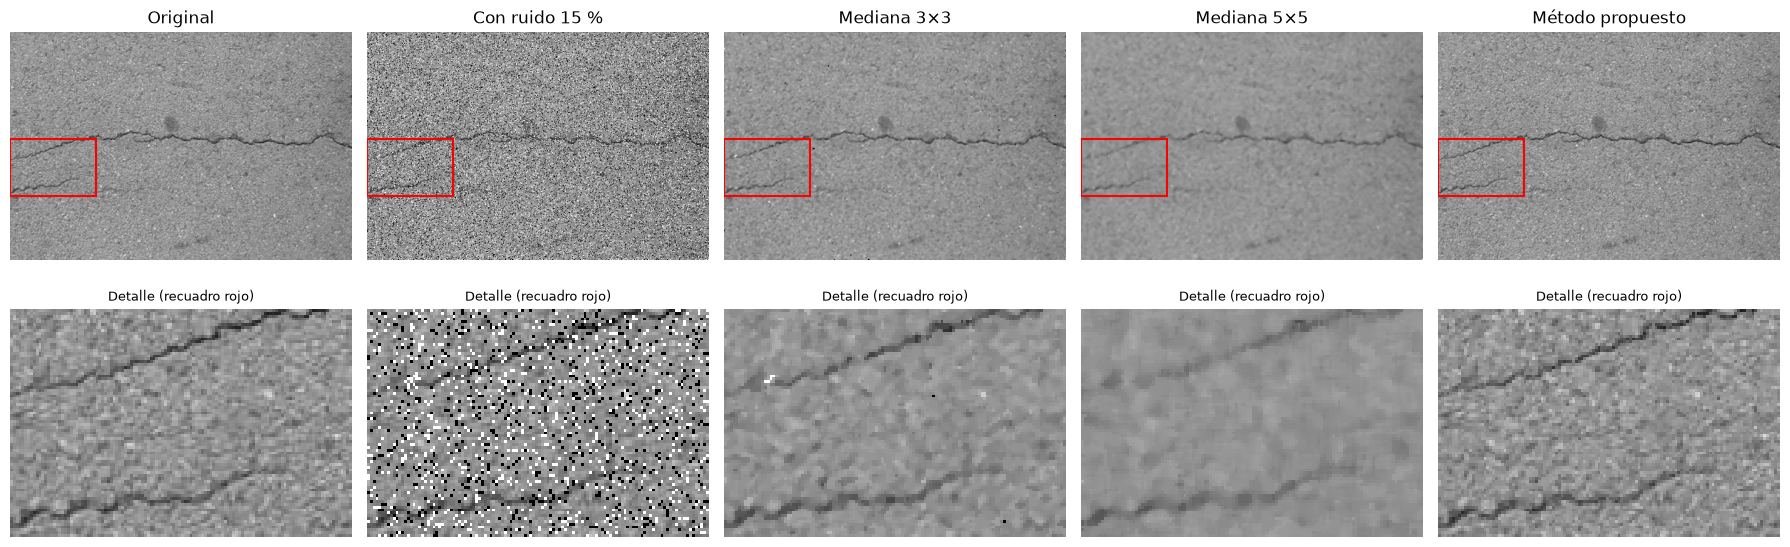

In [10]:
# Evaluación de la segunda etapa: corrección de impulsos

# Se evalúa la segunda etapa del método propuesto (corrección de impulsos) en la imagen 96, con un 15 % de ruido sal y pimienta.
restaurada = filtro_propuesto(ruidosa)
mediana3 = cv2.medianBlur(ruidosa, 3)
mediana5 = cv2.medianBlur(ruidosa, 5)

# Se genera un corte de la imagen 96 para mostrar un detalle de la fisura y la corrección de impulsos
y0, x0, alto_r, ancho_r = 150, 0, 80, 120
recorte = lambda m: m[y0:y0 + alto_r, x0:x0 + ancho_r]

# Visualización de la imagen original, la ruidosa, las medianas y la restaurada, con un recorte de detalle
paneles = [(img, "Original"), (ruidosa, "Con ruido 15 %"), (mediana3, "Mediana 3×3"),
           (mediana5, "Mediana 5×5"), (restaurada, "Método propuesto")]
fig, ejes = plt.subplots(2, 5, figsize=(18, 6))
for j, (dato, titulo) in enumerate(paneles):
    ejes[0, j].imshow(dato, cmap="gray", vmin=0, vmax=255)
    ejes[0, j].set_title(titulo)
    ejes[0, j].axis("off")
    ejes[0, j].add_patch(plt.Rectangle((x0, y0), ancho_r, alto_r, fill=False, edgecolor="red", linewidth=1.5))
    ejes[1, j].imshow(recorte(dato), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ejes[1, j].set_title("Detalle (recuadro rojo)", fontsize=9)
    ejes[1, j].axis("off")
plt.tight_layout()
plt.show()

En las anteriores imágenes se presentan la fotografía original (completa y un detalle de fisura), junto con la imagen con ruido con densidad de 15%. Las tres imágenes restantes muestran los resultados de la aplicación de filtros de mediana para las dos ventanas antes mencionadas y el resultado de la aplicación de la metodología propuesta en este Notebook. Es importante ver el efecto que generan los filtros de mediana sobre la imagen resultante, en este caso se evidencian perdidas en el detalle que permiten delimitar las fisuras, lo cual es un efecto no deseado. En contraste el resultado del método propuesto genera un resultado que se acerca mucho mejor a la imagen original, siendo justamente lo que se busca al eliminar el ruido.

### 5.3 Evaluación del resultado del filtrado con métricas PSNR y SSIM

A continuación se presentan los resultados de las métricas PSNR y SSIM para mostrar la calidad del resultado final del algoritmo de corrección de imágenes. En este caso se aplica para las cuatro imagenes propuestas inicialmente.

In [11]:
# Evaluación global: PSNR y SSIM para todas las imágenes y densidades

from IPython.display import Markdown, display

metodos = {
    "Mediana 3×3": lambda r: cv2.medianBlur(r, 3),
    "Mediana 5×5": lambda r: cv2.medianBlur(r, 5),
    "Método propuesto": filtro_propuesto,
}

# resultados[(imagen, densidad, método)] = (PSNR, PSNR fisura, SSIM)
resultados = {}
generador = np.random.default_rng(SEMILLA)
for n in IMAGENES:
    img, fisura = cargar_par(n)
    for d in DENSIDADES:
        ruidosa, _ = agregar_sal_pimienta(img, d, generador)
        for nombre, metodo in metodos.items():
            restaurada = metodo(ruidosa)
            resultados[(n, d, nombre)] = (psnr(img, restaurada),
                                          psnr(img, restaurada, fisura),
                                          ssim(img, restaurada))

def fila(etiqueta_img, etiqueta_d, valores_por_metodo):
    """Arma una fila de la tabla; resalta en negrita el mejor valor de cada métrica."""
    mejores = np.max(list(valores_por_metodo.values()), axis=0)
    celdas = []
    for valores in valores_por_metodo.values():
        partes = []
        for v, mejor, formato in zip(valores, mejores, ["{:.2f}", "{:.2f}", "{:.3f}"]):
            texto = formato.format(v)
            partes.append(f"**{texto}**" if np.isclose(v, mejor) else texto)
        celdas.append(" / ".join(partes))
    return f"| {etiqueta_img} | {etiqueta_d} | " + " | ".join(celdas) + " |"

encabezado = ("| Imagen | Densidad | " + " | ".join(metodos) + " |\n"
              "|---|---|" + "---|" * len(metodos))
lineas = [encabezado]
for n in IMAGENES:
    for d in DENSIDADES:
        lineas.append(fila(f"{n:03d}", f"{int(d * 100)} %",
                           {m: resultados[(n, d, m)] for m in metodos}))
for d in DENSIDADES:
    promedio = {m: np.mean([resultados[(n, d, m)] for n in IMAGENES], axis=0) for m in metodos}
    lineas.append(fila("**Promedio**", f"{int(d * 100)} %", promedio))

display(Markdown("Cada celda: **PSNR global (dB) / PSNR en fisura (dB) / SSIM**. "
                 "En negrita, el mejor valor de cada métrica en la fila.\n\n" + "\n".join(lineas)))

Cada celda: **PSNR global (dB) / PSNR en fisura (dB) / SSIM**. En negrita, el mejor valor de cada métrica en la fila.

| Imagen | Densidad | Mediana 3×3 | Mediana 5×5 | Método propuesto |
|---|---|---|---|---|
| 049 | 5 % | 33.57 / 29.76 / 0.823 | 30.69 / 26.74 / 0.626 | **45.19** / **40.30** / **0.990** |
| 049 | 15 % | 31.84 / 29.25 / 0.795 | 30.58 / 26.60 / 0.623 | **40.33** / **36.97** / **0.970** |
| 049 | 30 % | 24.51 / 23.70 / 0.612 | 30.24 / 26.01 / 0.615 | **35.71** / **32.97** / **0.926** |
| 096 | 5 % | 26.63 / 21.74 / 0.623 | 24.49 / 17.63 / 0.341 | **38.53** / **33.98** / **0.983** |
| 096 | 15 % | 26.04 / 21.02 / 0.600 | 24.41 / 17.60 / 0.338 | **33.54** / **28.33** / **0.945** |
| 096 | 30 % | 22.44 / 18.13 / 0.487 | 24.14 / 17.14 / 0.329 | **29.80** / **23.94** / **0.873** |
| 035 | 5 % | 26.62 / 24.26 / 0.632 | 24.49 / 21.35 / 0.361 | **38.60** / **35.89** / **0.984** |
| 035 | 15 % | 25.95 / 23.46 / 0.606 | 24.40 / 21.24 / 0.358 | **33.57** / **30.88** / **0.947** |
| 035 | 30 % | 22.22 / 20.23 / 0.488 | 24.09 / 20.82 / 0.347 | **29.53** / **26.56** / **0.872** |
| 097 | 5 % | 26.64 / 23.22 / 0.621 | 24.68 / 20.11 / 0.364 | **38.50** / **34.83** / **0.983** |
| 097 | 15 % | 25.97 / 22.64 / 0.597 | 24.57 / 20.01 / 0.360 | **33.55** / **29.54** / **0.945** |
| 097 | 30 % | 22.10 / 20.35 / 0.477 | 24.32 / 19.89 / 0.353 | **29.75** / **26.33** / **0.871** |
| **Promedio** | 5 % | 28.36 / 24.75 / 0.675 | 26.09 / 21.46 / 0.423 | **40.20** / **36.25** / **0.985** |
| **Promedio** | 15 % | 27.45 / 24.09 / 0.649 | 25.99 / 21.36 / 0.420 | **35.25** / **31.43** / **0.952** |
| **Promedio** | 30 % | 22.82 / 20.60 / 0.516 | 25.70 / 20.97 / 0.411 | **31.20** / **27.45** / **0.885** |

La tabla resumen los resultados de la métricas para las cuatro imágenes y las tres densidades de ruido de cada una. En todos lo casos el método propuesto muestra mejores resultados de corrección de la imagen que los métodos tradicionales de mediana para las ventanas de 3X3 y 5X5. Estos resultados muestran la capacidad de la propuesta para dar solución específica a la problemática presentada inicialmente y la potencialidad de las herramientas computacionales para la preparación de imágenes previo a procesos de análisis y reconocimiento en etapas posteriores.

## 6. Referencias bibliográficas

ASTM D6433. Standard practice for roads and parking lots pavement condition index surveys.

Chan, R. H., Ho, C.-W. y Nikolova, M. (2005). Salt-and-pepper noise removal by median-type noise detectors and detail-preserving regularization. IEEE Transactions on Image Processing, 14(10), 1479–1485.

Gonzalez, R. C. y Woods, R. E. (2018). Digital Image Processing (4.ª ed.). Pearson.

Hwang, H. y Haddad, R. A. (1995). Adaptive median filters: new algorithms and results. IEEE Transactions on Image Processing, 4(4), 499–502.

Koch, C., Georgieva, K., Kasireddy, V., Akinci, B. y Fieguth, P. (2015). A review on computer vision based defect detection and condition assessment of concrete and asphalt civil infrastructure. Advanced Engineering Informatics, 29(2), 196–210.

Zakeri, H., Nejad, F. M. y Fahimifar, A. (2017). Image based techniques for crack detection, classification and quantification in asphalt pavement: a review. Archives of Computational Methods in Engineering, 24(4), 935–977.

Shahin, M. Y. (2005). Pavement Management for Airports, Roads, and Parking Lots (2.ª ed.). Springer.

Shi, Y., Cui, L., Qi, Z., Meng, F. y Chen, Z. (2016). Automatic road crack detection using random structured forests. IEEE Transactions on Intelligent Transportation Systems, 17(12), 3434–3445.

UNIR. Material de la asignatura Percepción Computacional, temas 4 a 7.

Wang, Z., Bovik, A. C., Sheikh, H. R. y Simoncelli, E. P. (2004). Image quality assessment: from error visibility to structural similarity. IEEE Transactions on Image Processing, 13(4), 600–612.

